In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("archive.zip")

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [4]:
df.head(10)

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
5,6,8.7,48.9,75.0,7.2
6,7,57.5,32.8,23.5,11.8
7,8,120.2,19.6,11.6,13.2
8,9,8.6,2.1,1.0,4.8
9,10,199.8,2.6,21.2,10.6


In [5]:
df.isnull().sum()

,0
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [6]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [7]:
print(df.shape)

(200, 5)


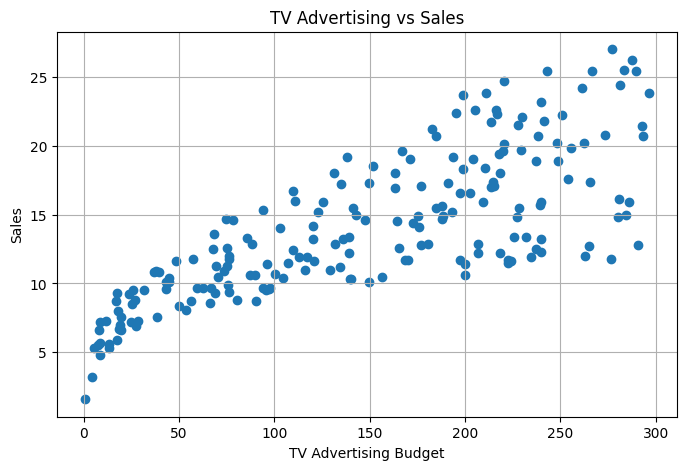

In [8]:
plt.figure(figsize=(8,5))
plt.scatter(df["TV"], df["Sales"])
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.title("TV Advertising vs Sales")
plt.grid(True)
plt.show()

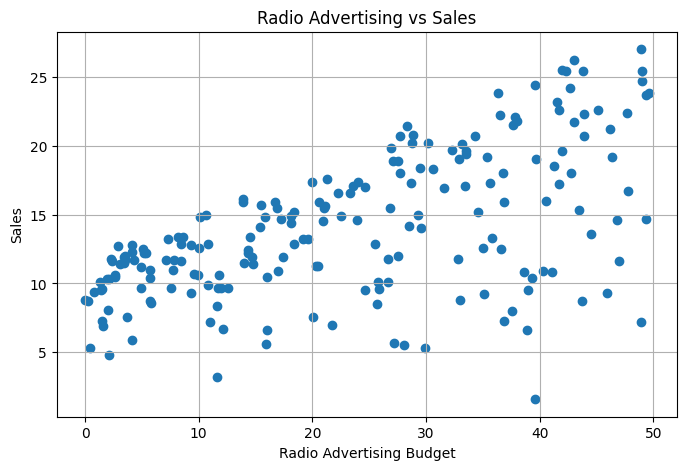

In [9]:
plt.figure(figsize=(8,5))
plt.scatter(df["Radio"], df["Sales"])
plt.xlabel("Radio Advertising Budget")
plt.ylabel("Sales")
plt.title("Radio Advertising vs Sales")
plt.grid(True)
plt.show()

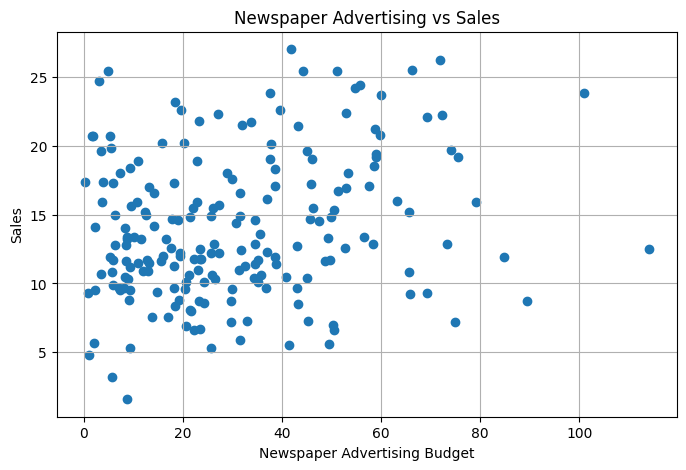

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(df["Newspaper"], df["Sales"])
plt.xlabel("Newspaper Advertising Budget")
plt.ylabel("Sales")
plt.title("Newspaper Advertising vs Sales")
plt.grid(True)
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

X = df[["TV","Radio","Newspaper"]]

y = df["Sales"]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train,y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [13]:
accuracy = model.score(X_test,y_test)

print("R² Score:",accuracy)

R² Score: 0.899438024100912


In [14]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326 13.10559172
 21.05719192  7.46101034 13.60634581 15.15506967]


In [15]:
comparison = pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred
})

comparison.head(10)

,Actual,Predicted
95,16.9,16.408024
15,22.4,20.889882
30,21.4,21.553843
158,7.3,10.608503
128,24.7,22.112373
115,12.6,13.105592
69,22.3,21.057192
170,8.4,7.461010
174,11.5,13.606346
45,14.9,15.155070


In [16]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print("Mean Absolute Error:",mae)
print("Mean Squared Error:",mse)
print("Root Mean Squared Error:",rmse)
print("R² Score:",r2)

Mean Absolute Error: 1.4607567168117603
Mean Squared Error: 3.1740973539761033
Root Mean Squared Error: 1.78159966153345
R² Score: 0.899438024100912


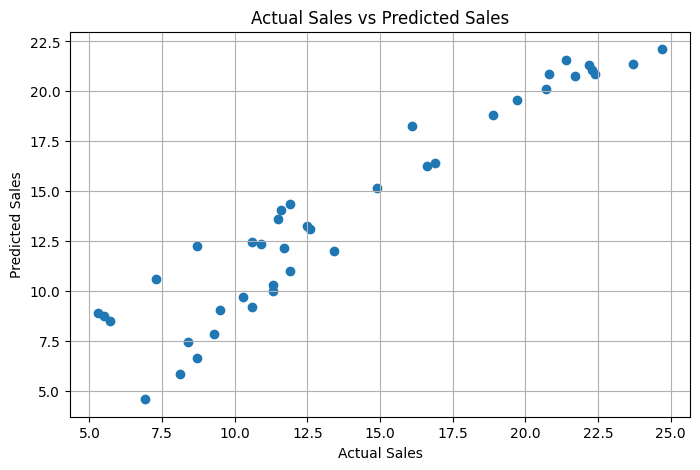

In [17]:
plt.figure(figsize=(8,5))

plt.scatter(y_test,y_pred)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual Sales vs Predicted Sales")

plt.grid(True)

plt.show()

In [19]:
import pandas as pd

tv = float(input("Enter TV Advertising Budget: "))
radio = float(input("Enter Radio Advertising Budget: "))
news = float(input("Enter Newspaper Advertising Budget: "))

new_data = pd.DataFrame({
    "TV": [tv],
    "Radio": [radio],
    "Newspaper": [news]
})

prediction = model.predict(new_data)

print("Predicted Sales:", prediction[0])

Enter TV Advertising Budget: 230.1
Enter Radio Advertising Budget: 37.8
Enter Newspaper Advertising Budget: 69.2
Predicted Sales: 20.613971470156297


Conclusion

This project predicts product sales using advertising expenditure on TV, Radio and Newspaper.

The dataset was cleaned and analyzed.

Different graphs were used to understand the relationship between advertising and sales.

A Linear Regression model was trained to predict sales.

The model was evaluated using R² Score, MAE, MSE and RMSE.

This project demonstrates practical machine learning, data visualization, regression analysis and prediction using Python.